In [2]:
'''Analyze transaction data to identify patterns and 
associations between products, enabling recommendations and optimizing product 
placement'''


#import the all librarys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx


feature_store=pd.read_csv(r"D:\Project (Navodita infotech)\Market Basket Analysis-[Rohit Kumar Prajapati]\feature_store.csv")
instacart=pd.read_csv(r"D:\Project (Navodita infotech)\Market Basket Analysis-[Rohit Kumar Prajapati]\instacart_processed.csv")

feature_store.head()
instacart.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,8,23423,1,1,3107,prior,5,4,6,17.0,Original Hawaiian Sweet Rolls,43,3,buns rolls,bakery
1,40,10070,1,1,382,prior,29,1,15,23.0,Organic 1% Low Fat Milk,84,16,milk,dairy eggs
2,40,42450,2,1,382,prior,29,1,15,23.0,Macaroni & Cheese,38,1,frozen meals,frozen
3,40,33198,3,1,382,prior,29,1,15,23.0,Sparkling Natural Mineral Water,115,7,water seltzer sparkling water,beverages
4,40,34866,4,1,382,prior,29,1,15,23.0,Chocolate Milk 1% Milkfat,84,16,milk,dairy eggs


                 DATA CLEANING

INSTACART DATASET

Shape Before Cleaning : (761750, 15)

Duplicate Rows : 0
No duplicate rows found.

Missing Values
No Missing Values Found.

Extra spaces removed.

Shape After Cleaning : (761750, 15)
Memory Usage : 196.63 MB

Remaining Missing Values : 0
Remaining Duplicate Rows : 0

FEATURE STORE DATASET

Shape Before Cleaning : (313370, 39)

Duplicate Rows : 0
No duplicate rows found.

Missing Values
No Missing Values Found.

Extra spaces removed.
Negative values found in hour_sin
Negative values found in hour_cos

Shape After Cleaning : (313370, 39)
Memory Usage : 30.78 MB

Remaining Missing Values : 0
Remaining Duplicate Rows : 0

DATA CLEANING COMPLETED SUCCESSFULLY
                 EXPLORATORY DATA ANALYSIS

DATASET SUMMARY
Total Orders      : 76,832
Total Users       : 5,000
Total Products    : 28,854
Total Departments : 21
Total Aisles      : 134


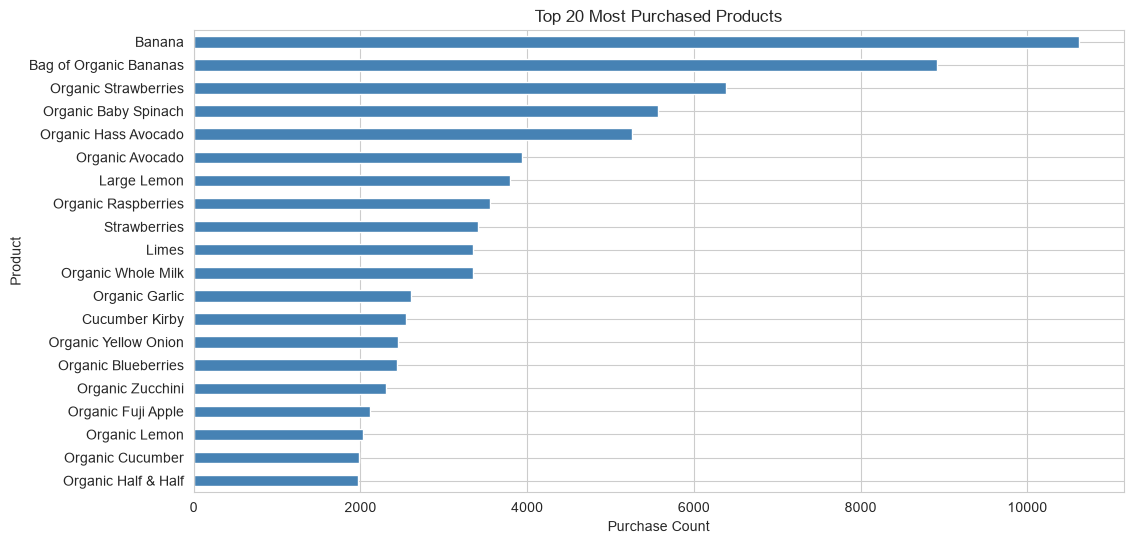

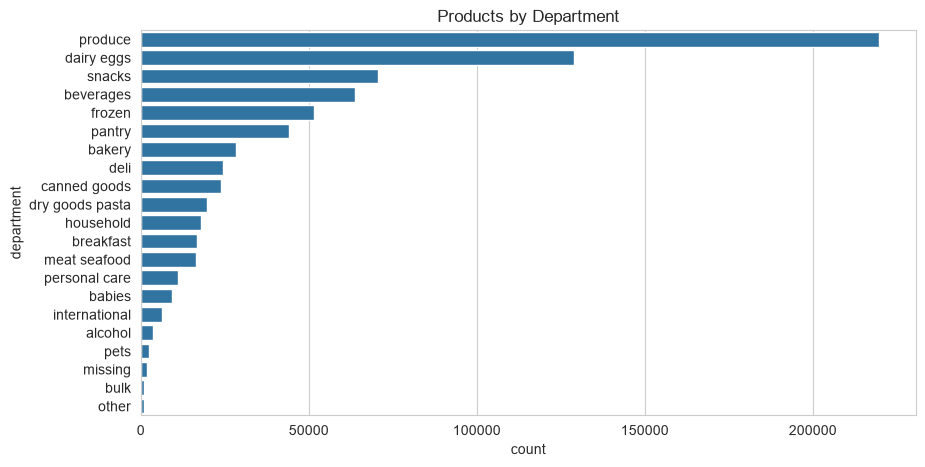

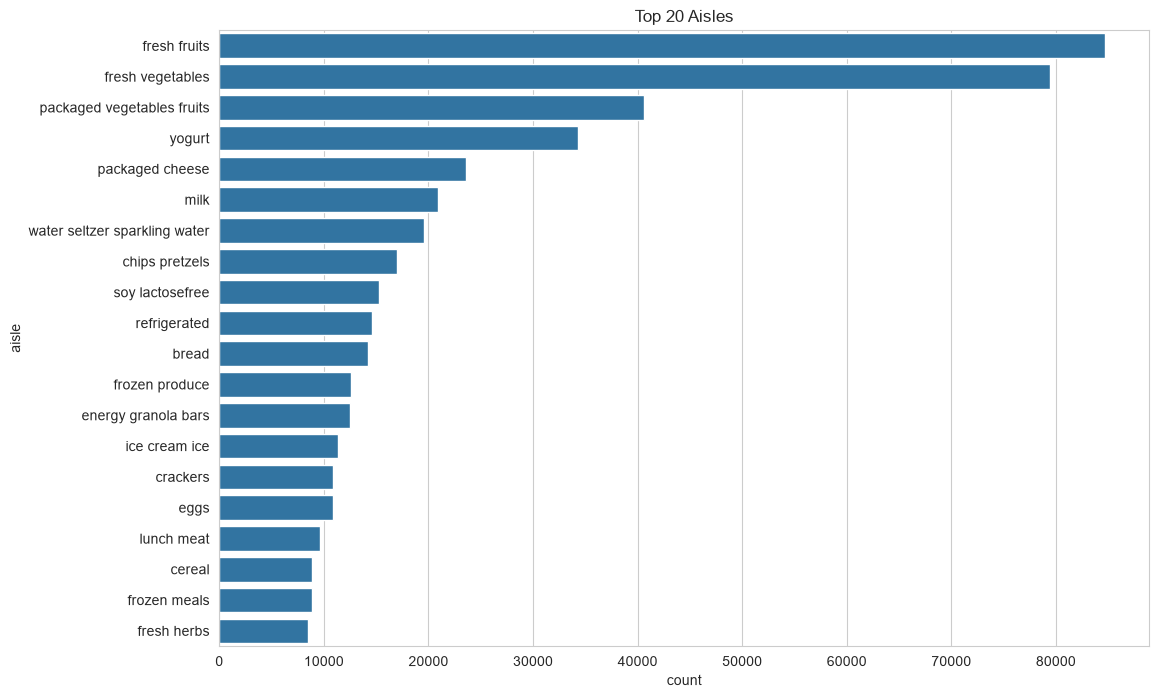

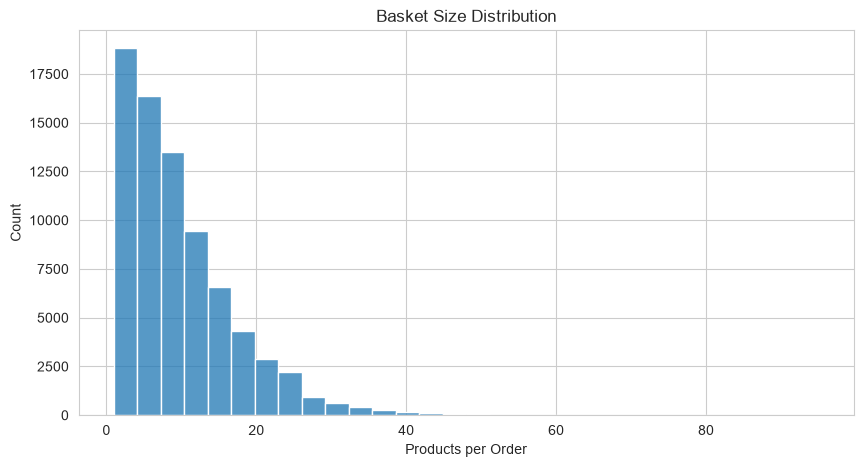

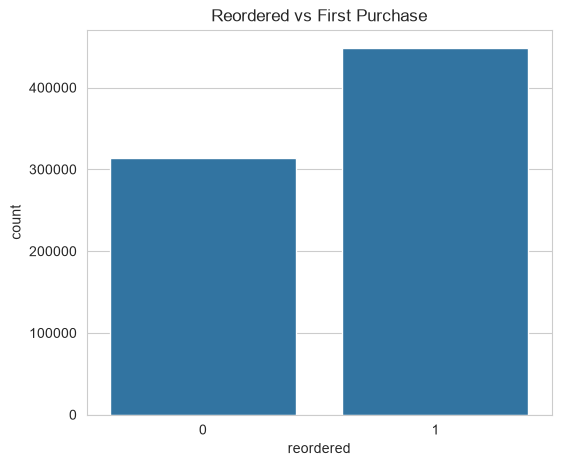

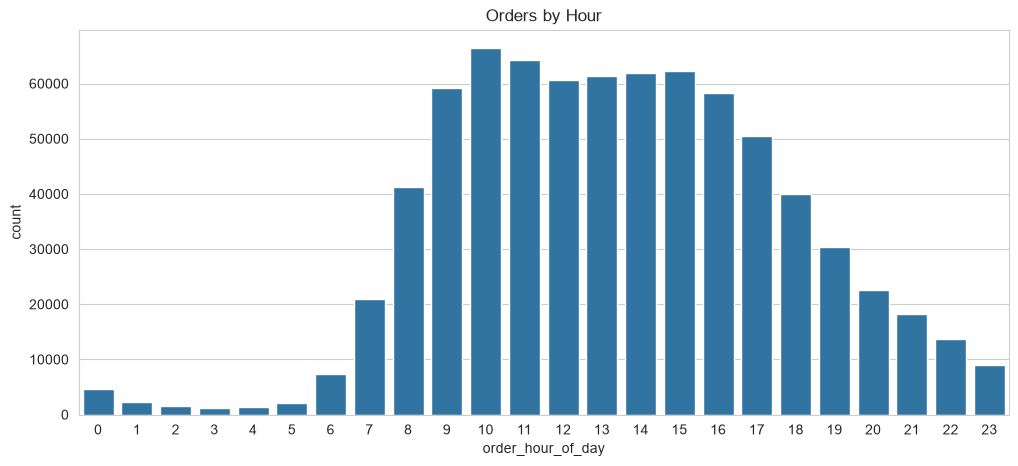

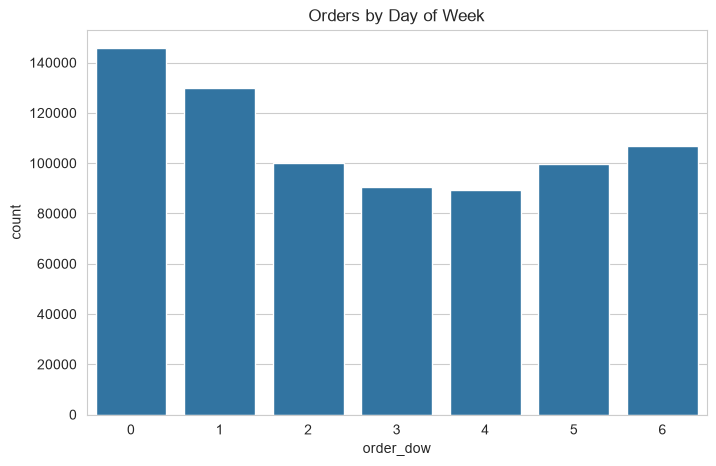

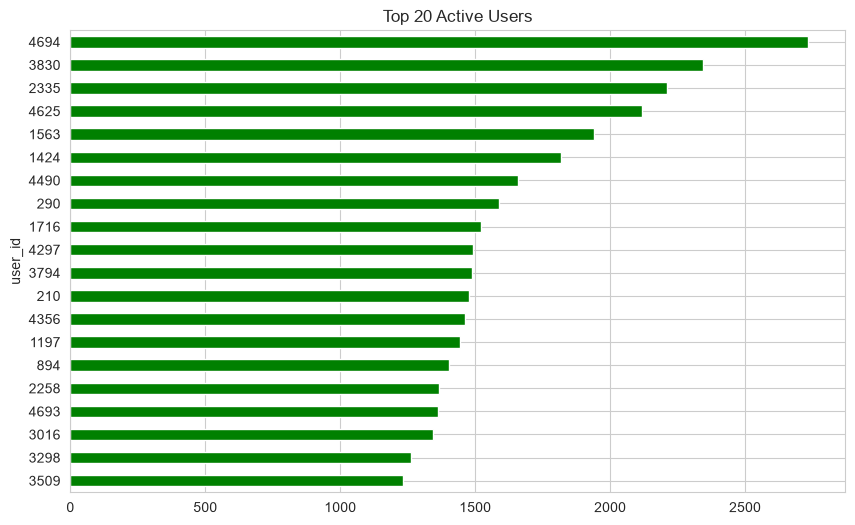

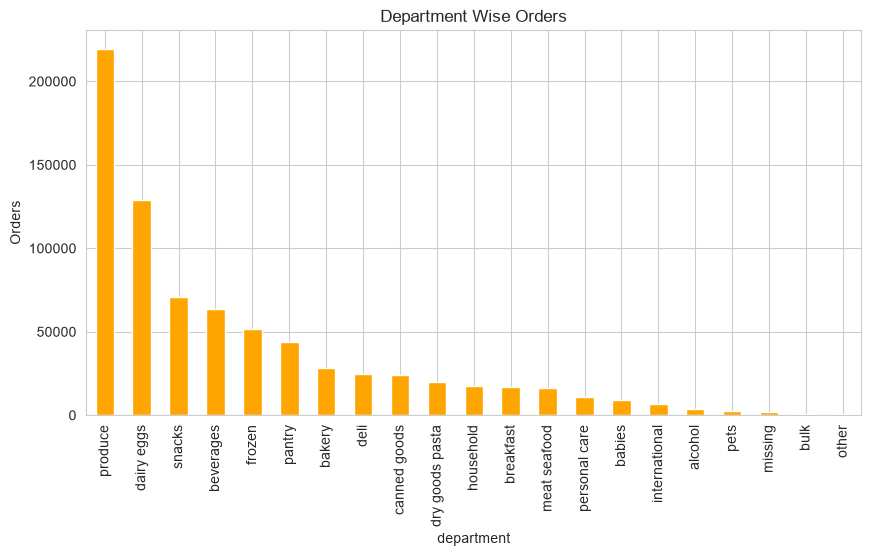

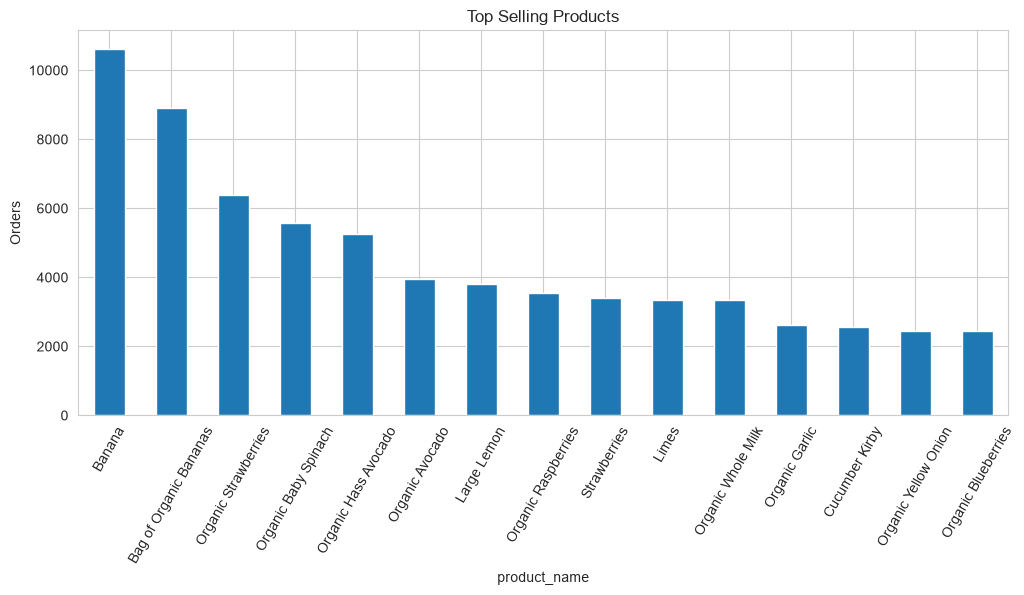


FEATURE STORE SUMMARY


,user_id,product_id,user_product_orders,user_product_first_order,user_product_last_order,user_product_avg_cart_position,user_product_reorder_rate,user_product_order_rate,orders_since_last_purchase,user_total_orders,...,aisle_popularity,churn,is_weekend,is_morning,is_evening,hour_sin,hour_cos,add_to_cart_order,reordered,label
count,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,...,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000,313370.000000
mean,2512.105661,25508.193640,2.430833,10.464074,15.517168,9.128829,0.264997,0.294753,5.053094,24.775275,...,23821.998883,0.304678,0.341364,0.325709,0.234156,-0.206884,-0.505083,9.128829,0.399464,0.399464
std,1448.598829,14209.171568,3.560034,13.290140,17.150451,7.005396,0.339540,0.278305,11.550277,22.101780,...,28709.284302,0.460272,0.421220,0.411679,0.372579,0.570457,0.471359,7.005396,0.489789,0.489789
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.010101,0.000000,3.000000,...,123.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000
25%,1264.000000,13343.500000,1.000000,2.000000,4.000000,4.000000,0.000000,0.090909,0.000000,9.000000,...,5473.000000,0.000000,0.000000,0.000000,0.000000,-0.707107,-0.866025,4.000000,0.000000,0.000000
50%,2501.000000,25630.000000,1.000000,5.000000,9.000000,7.285714,0.000000,0.200000,0.000000,17.000000,...,8836.000000,0.000000,0.000000,0.000000,0.000000,-0.258819,-0.683013,7.285714,0.000000,0.000000
75%,3776.000000,38063.000000,2.000000,13.000000,20.000000,12.000000,0.500000,0.400000,4.000000,33.000000,...,34279.000000,1.000000,0.800000,0.666667,0.400000,0.258819,-0.258819,12.000000,1.000000,1.000000
max,5000.000000,49683.000000,91.000000,99.000000,99.000000,91.000000,0.989011,1.000000,98.000000,99.000000,...,84695.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,91.000000,1.000000,1.000000


<Figure size 1500x800 with 0 Axes>

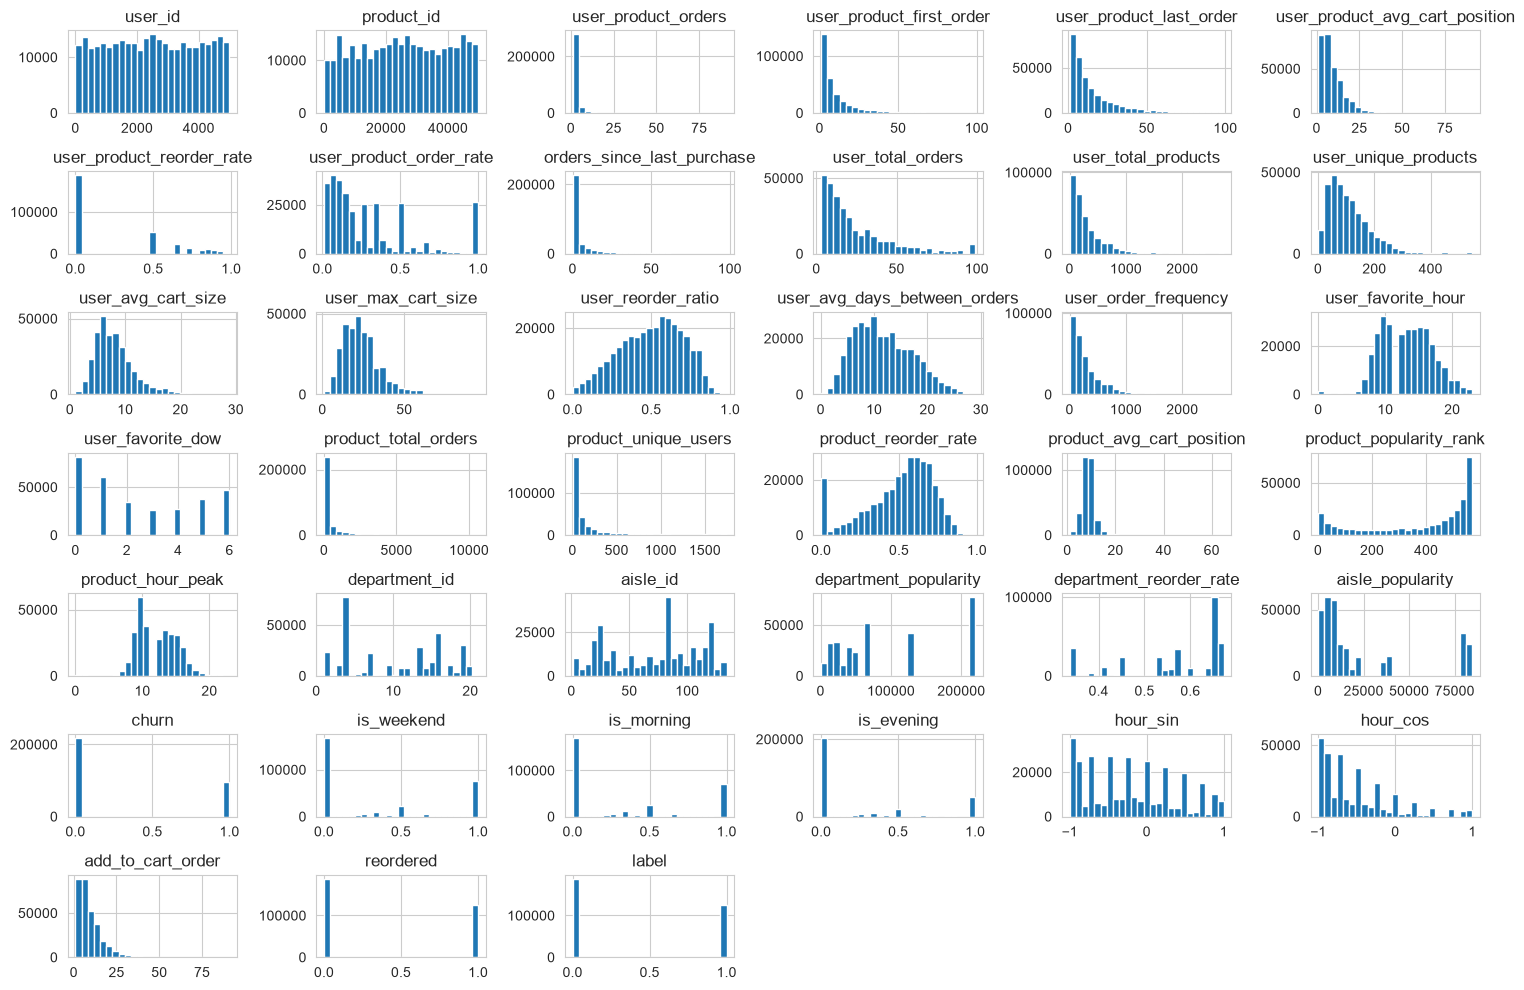

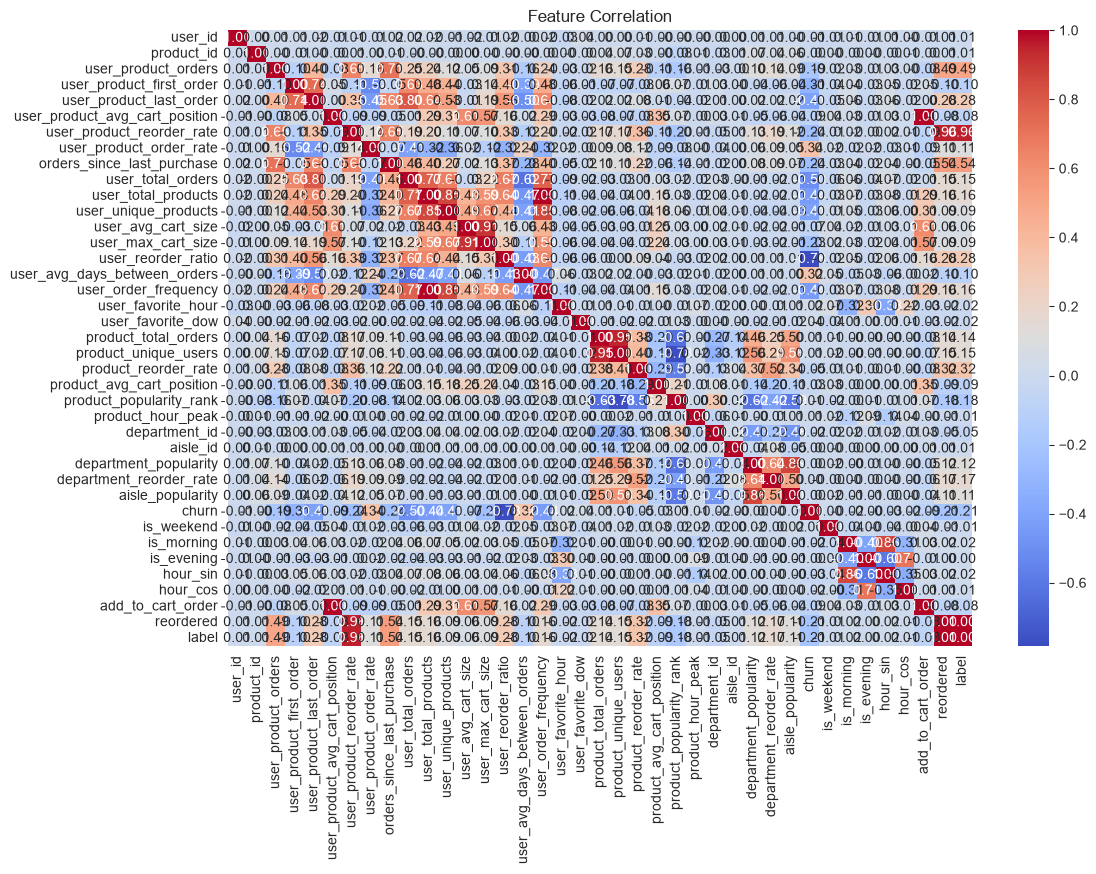

BUSINESS INSIGHTS
1. Top selling products identified.
2. Most active departments identified.
3. Customer ordering behaviour analysed.
4. Peak ordering hours identified.
5. Basket size distribution analysed.
6. Reordered products analysed.
7. Most active customers identified.
8. Feature relationships analysed.

EDA Completed Successfully.
                 MARKET BASKET ANALYSIS
Transaction Matrix Shape: (67125, 500)


product_name,0% Greek Strained Yogurt,1% Lowfat Milk,100 Calorie Per Bag Popcorn,100% Raw Coconut Water,100% Recycled Paper Towels,100% Whole Wheat Bread,2% Reduced Fat DHA Omega-3 Reduced Fat Milk,2% Reduced Fat Milk,2% Reduced Fat Organic Milk,Aged White Cheddar Baked Rice & Corn Puffs Gluten Free Lunch Packs,...,Whole Wheat Bread,Wild Berry Smoothie,XL Emerald White Seedless Grapes,Yellow Bell Pepper,Yellow Onions,YoKids Blueberry & Strawberry/Vanilla Yogurt,"YoKids Squeezers Organic Low-Fat Yogurt, Strawberry","Yogurt, Strained Low-Fat, Coconut",Yotoddler Organic Pear Spinach Mango Yogurt,Zero Calorie Cola
order_id,,,,,,,,,,,,,,,,,,,,,
40,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
102,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
104,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Encoded Transaction Matrix


product_name,0% Greek Strained Yogurt,1% Lowfat Milk,100 Calorie Per Bag Popcorn,100% Raw Coconut Water,100% Recycled Paper Towels,100% Whole Wheat Bread,2% Reduced Fat DHA Omega-3 Reduced Fat Milk,2% Reduced Fat Milk,2% Reduced Fat Organic Milk,Aged White Cheddar Baked Rice & Corn Puffs Gluten Free Lunch Packs,...,Whole Wheat Bread,Wild Berry Smoothie,XL Emerald White Seedless Grapes,Yellow Bell Pepper,Yellow Onions,YoKids Blueberry & Strawberry/Vanilla Yogurt,"YoKids Squeezers Organic Low-Fat Yogurt, Strawberry","Yogurt, Strained Low-Fat, Coconut",Yotoddler Organic Pear Spinach Mango Yogurt,Zero Calorie Cola
order_id,,,,,,,,,,,,,,,,,,,,,
40,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
74,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
85,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
102,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
104,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False



Average Basket Size : 4.88
Maximum Basket Size : 46
Minimum Basket Size : 1

Generating Frequent Itemsets...

Top Frequent Itemsets


...

TOP CROSS SELLING OPPORTUNITIES


,Antecedent,Consequent,support,confidence,lift
23,Organic Raspberries,Organic Strawberries,0.013825,0.260674,2.740876
22,Organic Strawberries,Organic Raspberries,0.013825,0.145363,2.740876
12,Bag of Organic Bananas,Organic Raspberries,0.015777,0.118709,2.238292
13,Organic Raspberries,Bag of Organic Bananas,0.015777,0.297472,2.238292
0,Bag of Organic Bananas,Organic Hass Avocado,0.022823,0.171730,2.194432
1,Organic Hass Avocado,Bag of Organic Bananas,0.022823,0.291643,2.194432
15,Organic Hass Avocado,Organic Strawberries,0.015747,0.201218,2.115724
14,Organic Strawberries,Organic Hass Avocado,0.015747,0.165570,2.115724
34,Organic Baby Spinach,Organic Avocado,0.010175,0.122621,2.089603
35,Organic Avocado,Organic Baby Spinach,0.010175,0.173394,2.089603


TOP PRODUCT BUNDLES


,support,itemsets,length
117,0.022823,"(Bag of Organic Bananas, Organic Hass Avocado)",2
119,0.022764,"(Organic Strawberries, Bag of Organic Bananas)",2
127,0.017728,"(Organic Strawberries, Banana)",2
124,0.017698,"(Banana, Organic Avocado)",2
116,0.017162,"(Bag of Organic Bananas, Organic Baby Spinach)",2
125,0.016790,"(Banana, Organic Baby Spinach)",2
118,0.015777,"(Bag of Organic Bananas, Organic Raspberries)",2
132,0.015747,"(Organic Strawberries, Organic Hass Avocado)",2
122,0.014898,"(Banana, Large Lemon)",2
128,0.014272,"(Banana, Strawberries)",2


PRODUCT ASSOCIATION NETWORK


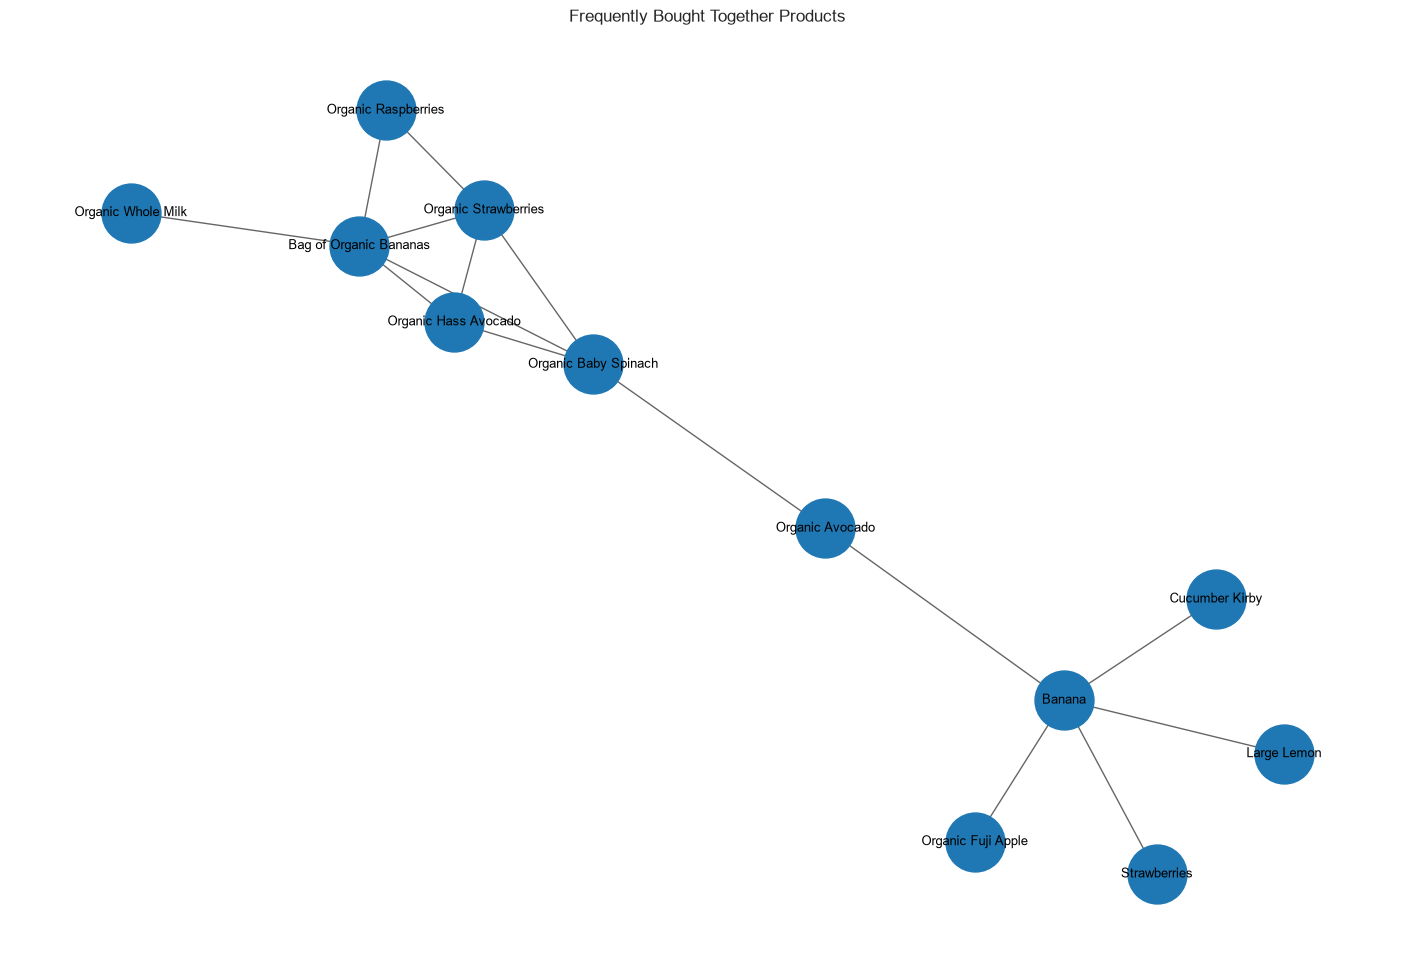

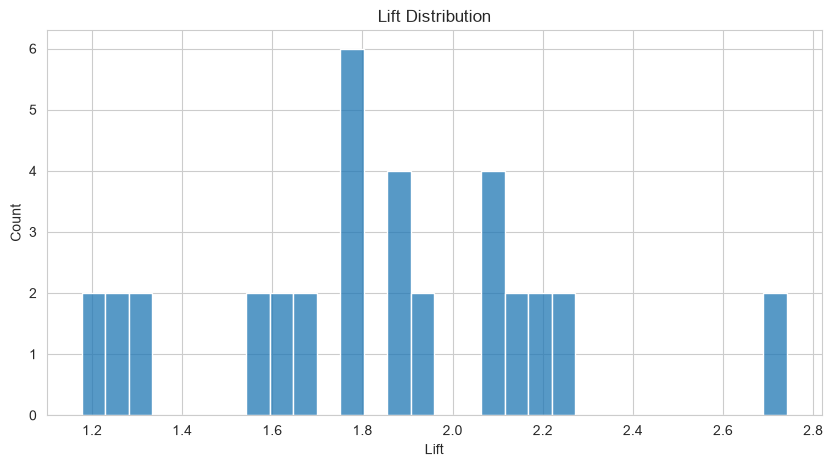

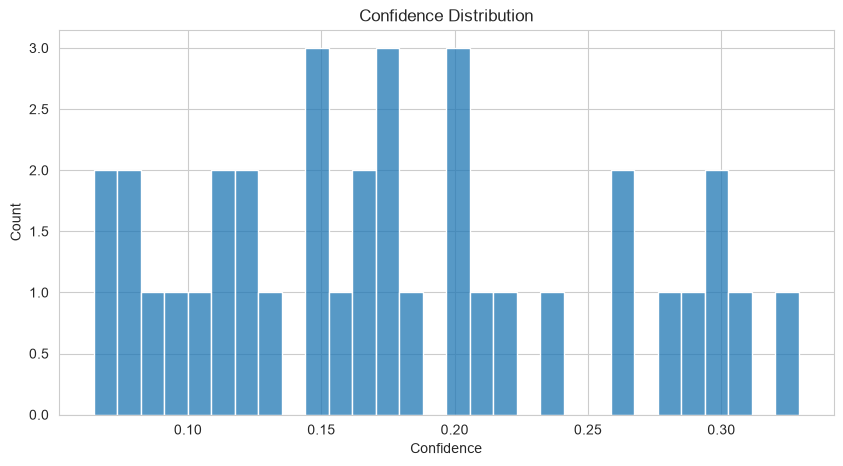

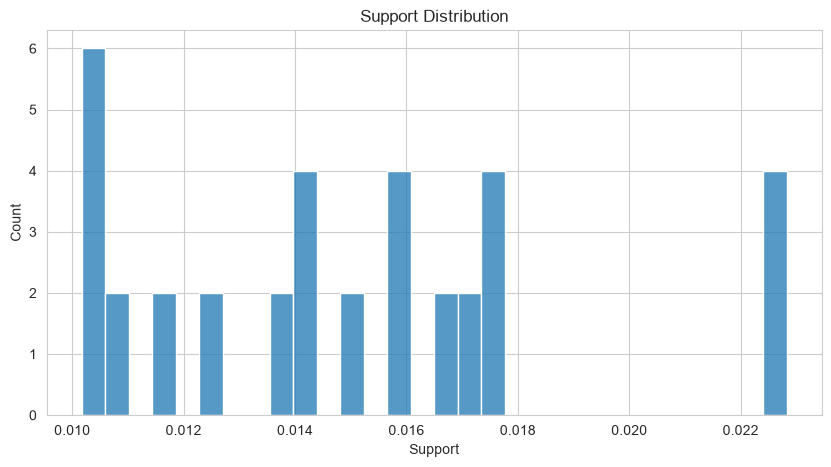

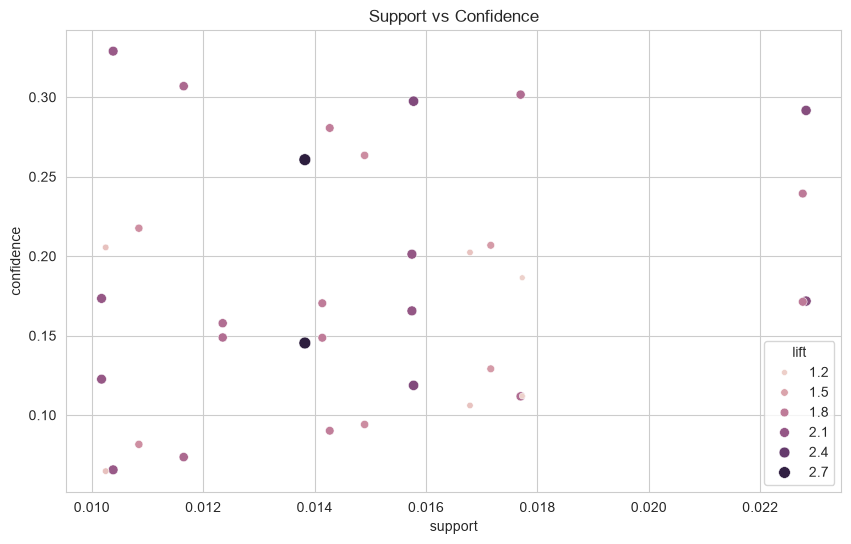

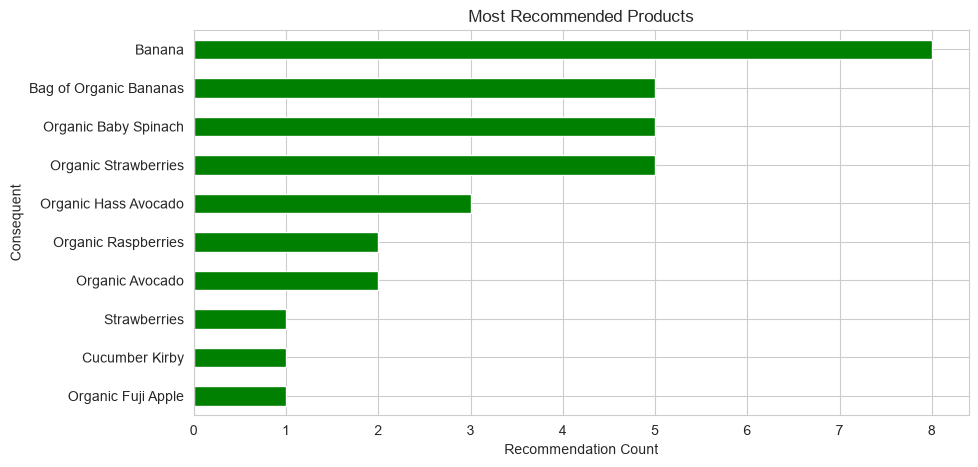

BUSINESS INSIGHTS

1. Products with highest lift should be placed near each other.

2. Bundle offers should be created for high-confidence product pairs.

3. Frequently purchased products should appear in recommendation engines.

4. High support products should always remain in stock.

5. Frequently reordered products indicate customer loyalty.

6. Cross-selling campaigns should target strong association rules.

7. Low support but high lift products can generate premium bundle opportunities.

8. Product placement can be optimized using frequent itemsets.

PRODUCT RECOMMENDATION COMPLETED SUCCESSFULLY
                 FINAL BUSINESS REPORT

Total Orders        : 76,832
Total Users         : 5,000
Total Products      : 28,854
Total Departments   : 21
Total Aisles        : 134

TOP 10 BEST SELLING PRODUCTS


,Product,Orders
0,Banana,10625
1,Bag of Organic Bananas,8921
2,Organic Strawberries,6384
3,Organic Baby Spinach,5570
4,Organic Hass Avocado,5253
5,Organic Avocado,3939
6,Large Lemon,3797
7,Organic Raspberries,3560
8,Strawberries,3414
9,Limes,3348


TOP DEPARTMENTS


,Department,Orders
0,produce,219676
1,dairy eggs,128801
2,snacks,70538
3,beverages,63757
4,frozen,51523
5,pantry,44107
6,bakery,28291
7,deli,24514
8,canned goods,23918
9,dry goods pasta,19627


TOP AISLES


...

TOP ASSOCIATION RULES


,Antecedent,Consequent,support,confidence,lift
23,Organic Raspberries,Organic Strawberries,0.013825,0.260674,2.740876
22,Organic Strawberries,Organic Raspberries,0.013825,0.145363,2.740876
12,Bag of Organic Bananas,Organic Raspberries,0.015777,0.118709,2.238292
13,Organic Raspberries,Bag of Organic Bananas,0.015777,0.297472,2.238292
0,Bag of Organic Bananas,Organic Hass Avocado,0.022823,0.171730,2.194432
1,Organic Hass Avocado,Bag of Organic Bananas,0.022823,0.291643,2.194432
15,Organic Hass Avocado,Organic Strawberries,0.015747,0.201218,2.115724
14,Organic Strawberries,Organic Hass Avocado,0.015747,0.165570,2.115724
35,Organic Avocado,Organic Baby Spinach,0.010175,0.173394,2.089603
34,Organic Baby Spinach,Organic Avocado,0.010175,0.122621,2.089603


BEST PRODUCT BUNDLES


,support,itemsets,length
117,0.022823,"(Bag of Organic Bananas, Organic Hass Avocado)",2
119,0.022764,"(Organic Strawberries, Bag of Organic Bananas)",2
127,0.017728,"(Organic Strawberries, Banana)",2
124,0.017698,"(Banana, Organic Avocado)",2
116,0.017162,"(Bag of Organic Bananas, Organic Baby Spinach)",2
125,0.016790,"(Banana, Organic Baby Spinach)",2
118,0.015777,"(Bag of Organic Bananas, Organic Raspberries)",2
132,0.015747,"(Organic Strawberries, Organic Hass Avocado)",2
122,0.014898,"(Banana, Large Lemon)",2
128,0.014272,"(Banana, Strawberries)",2


BUSINESS RECOMMENDATIONS
1. Place frequently bought together products on nearby shelves.
2. Create combo offers using high-confidence product pairs.
3. Display recommended products on checkout pages.
4. Keep high-support products well stocked.
5. Promote products with high lift through cross-selling campaigns.
6. Bundle premium products to increase average order value.
7. Use recommendation rules in mobile and web applications.
8. Review association rules regularly as customer buying behavior changes.
PROJECT CONCLUSION

Market Basket Analysis successfully identified purchasing patterns
between products using the Apriori Algorithm.

The association rules revealed which products customers frequently buy together.
These insights can improve:

• Product Recommendation Systems
• Cross-selling Strategies
• Store Shelf Placement
• Promotional Bundle Design
• Customer Shopping Experience
• Inventory Planning

Overall, the analysis provides actionable insights that help retailers
increase sale

In [6]:
# ==========================================================
# DATA CLEANING
# ==========================================================

print("="*100)
print("                 DATA CLEANING")
print("="*100)

datasets = {
    "Instacart Dataset": instacart,
    "Feature Store Dataset": feature_store
}

for name, df in datasets.items():

    print("\n" + "="*100)
    print(name.upper())
    print("="*100)

    # -----------------------------
    # Shape Before Cleaning
    # -----------------------------
    print("\nShape Before Cleaning :", df.shape)

    # -----------------------------
    # Remove Duplicate Rows
    # -----------------------------
    duplicate_rows = df.duplicated().sum()

    print("\nDuplicate Rows :", duplicate_rows)

    if duplicate_rows > 0:
        df.drop_duplicates(inplace=True)
        print("Duplicate rows removed successfully.")
    else:
        print("No duplicate rows found.")

    # -----------------------------
    # Missing Values
    # -----------------------------
    print("\nMissing Values")

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print("No Missing Values Found.")
    else:
        display(missing)

        # Numeric Columns
        numeric_cols = df.select_dtypes(include=np.number).columns

        for col in numeric_cols:
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].median(), inplace=True)

        # Categorical Columns
        categorical_cols = df.select_dtypes(include="object").columns

        for col in categorical_cols:
            if df[col].isnull().sum() > 0:
                df[col].fillna(df[col].mode()[0], inplace=True)

        print("Missing values handled successfully.")

    # -----------------------------
    # Remove Extra Spaces
    # -----------------------------
    object_cols = df.select_dtypes(include="object").columns

    for col in object_cols:
        df[col] = df[col].astype(str).str.strip()

    print("\nExtra spaces removed.")

    # -----------------------------
    # Remove Completely Empty Rows
    # -----------------------------
    df.dropna(how="all", inplace=True)

    # -----------------------------
    # Reset Index
    # -----------------------------
    df.reset_index(drop=True, inplace=True)

    # -----------------------------
    # Invalid Numeric Values
    # -----------------------------
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:

        if (df[col] < 0).sum() > 0:

            print(f"Negative values found in {col}")

    # -----------------------------
    # Data Type Optimization
    # -----------------------------
    for col in df.select_dtypes(include="int64").columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in df.select_dtypes(include="float64").columns:
        df[col] = pd.to_numeric(df[col], downcast="float")

    # -----------------------------
    # Memory Usage
    # -----------------------------
    memory = round(df.memory_usage(deep=True).sum()/1024**2,2)

    # -----------------------------
    # Shape After Cleaning
    # -----------------------------
    print("\nShape After Cleaning :", df.shape)

    print("Memory Usage :", memory,"MB")

    # -----------------------------
    # Final Missing Values
    # -----------------------------
    print("\nRemaining Missing Values :", df.isnull().sum().sum())

    # -----------------------------
    # Final Duplicate Rows
    # -----------------------------
    print("Remaining Duplicate Rows :", df.duplicated().sum())

print("\n" + "="*100)
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("="*100)


# ==========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

sns.set_style("whitegrid")
print("="*100)
print("                 EXPLORATORY DATA ANALYSIS")
print("="*100)

# -----------------------------
# KPI Summary
# -----------------------------
print("\nDATASET SUMMARY")

print(f"Total Orders      : {instacart['order_id'].nunique():,}")
print(f"Total Users       : {instacart['user_id'].nunique():,}")
print(f"Total Products    : {instacart['product_name'].nunique():,}")
print(f"Total Departments : {instacart['department'].nunique():,}")
print(f"Total Aisles      : {instacart['aisle'].nunique():,}")

# ==========================================================
# Top 20 Products
# ==========================================================

plt.figure(figsize=(12,6))
instacart['product_name'].value_counts().head(20).sort_values().plot(
    kind='barh',
    color='steelblue'
)
plt.title("Top 20 Most Purchased Products")
plt.xlabel("Purchase Count")
plt.ylabel("Product")
plt.savefig("Market Basket Analysis-1")
plt.show()

# ==========================================================
# Top Departments
# ==========================================================

plt.figure(figsize=(10,5))
sns.countplot(
    data=instacart,
    y='department',
    order=instacart['department'].value_counts().index,
)
plt.title("Products by Department")
plt.savefig("Market Basket Analysis-2")
plt.show()

# ==========================================================
# Top Aisles
# ==========================================================

plt.figure(figsize=(12,8))
sns.countplot(
    data=instacart,
    y='aisle',
    order=instacart['aisle'].value_counts().head(20).index
)
plt.title("Top 20 Aisles")
plt.savefig("Market Basket Analysis-3")
plt.show()

# ==========================================================
# Basket Size Distribution
# ==========================================================

basket_size = instacart.groupby('order_id')['product_name'].count()
plt.figure(figsize=(10,5))
sns.histplot(
    basket_size,
    bins=30
)
plt.title("Basket Size Distribution")
plt.xlabel("Products per Order")
plt.savefig("Market Basket Analysis-4")
plt.show()

# ==========================================================
# Reordered Products
# ==========================================================

plt.figure(figsize=(6,5))
sns.countplot(
    data=instacart,
    x='reordered'
)
plt.title("Reordered vs First Purchase")
plt.savefig("Market Basket Analysis-5")
plt.show()

# ==========================================================
# Orders by Hour
# ==========================================================

plt.figure(figsize=(12,5))
sns.countplot(
    data=instacart,
    x='order_hour_of_day'
)
plt.title("Orders by Hour")
plt.savefig("Market Basket Analysis-6")
plt.show()

# ==========================================================
# Orders by Day
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=instacart,
    x='order_dow'
)

plt.title("Orders by Day of Week")
plt.savefig("Market Basket Analysis-7")
plt.show()

# ==========================================================
# Top Users
# ==========================================================

plt.figure(figsize=(10,6))
instacart['user_id'].value_counts().head(20).sort_values().plot(
    kind='barh',
    color='green'
)
plt.title("Top 20 Active Users")
plt.savefig("Market Basket Analysis-8")
plt.show()

# ==========================================================
# Top 10 Departments
# ==========================================================

dept = instacart.groupby('department')['order_id'].count().sort_values(ascending=False)
plt.figure(figsize=(10,5))
dept.plot(kind='bar',color='orange')
plt.title("Department Wise Orders")
plt.ylabel("Orders")
plt.savefig("Market Basket Analysis-9")
plt.show()

# ==========================================================
# Top 15 Products
# ==========================================================

top_products = instacart.groupby('product_name')['order_id'].count().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,5))
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.ylabel("Orders")
plt.xticks(rotation=60)
plt.savefig("Market Basket Analysis-10")
plt.show()

# ==========================================================
# Feature Store Analysis
# ==========================================================

print("\nFEATURE STORE SUMMARY")
display(feature_store.describe())
numeric_cols = feature_store.select_dtypes(include='number').columns
plt.figure(figsize=(15,8))
feature_store[numeric_cols].hist(
    bins=25,
    figsize=(15,10)
)
plt.tight_layout()
plt.savefig("Market Basket Analysis-11")
plt.show()

# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(12,8))
sns.heatmap(
    feature_store[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Feature Correlation")
plt.savefig("Market Basket Analysis-12")
plt.show()

# ==========================================================
# Business Insights
# ==========================================================

print("="*100)
print("BUSINESS INSIGHTS")
print("="*100)
print("1. Top selling products identified.")
print("2. Most active departments identified.")
print("3. Customer ordering behaviour analysed.")
print("4. Peak ordering hours identified.")
print("5. Basket size distribution analysed.")
print("6. Reordered products analysed.")
print("7. Most active customers identified.")
print("8. Feature relationships analysed.")

print("\nEDA Completed Successfully.")


# ==========================================================
# MARKET BASKET ANALYSIS (Apriori Algorithm)
# ==========================================================

print("="*100)
print("                 MARKET BASKET ANALYSIS")
print("="*100)

# ==========================================================
# Filter Top Products (Reduce Memory Usage)
# ==========================================================

TOP_PRODUCTS = 500   # You can keep 300, 500 or 1000

top_products = (
    instacart["product_name"]
    .value_counts()
    .head(TOP_PRODUCTS)
    .index
)

instacart_small = instacart[
    instacart["product_name"].isin(top_products)
]

# ==========================================================
# Create Transaction Matrix
# ==========================================================

basket = (
    instacart_small
    .groupby(["order_id", "product_name"])["product_name"]
    .count()
    .unstack(fill_value=0)
)

# Convert to Boolyean (0/1)
basket = basket.astype(bool)

print("Transaction Matrix Shape:", basket.shape)
display(basket.head())

print("\nEncoded Transaction Matrix")
display(basket.head())

# ----------------------------------------------------------
# Average Basket Size
# ----------------------------------------------------------

basket_size = basket.sum(axis=1)
print("\nAverage Basket Size :", round(basket_size.mean(),2))
print("Maximum Basket Size :", basket_size.max())
print("Minimum Basket Size :", basket_size.min())

# ----------------------------------------------------------
# Frequent Itemsets
# ----------------------------------------------------------

print("\nGenerating Frequent Itemsets...")
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)
print("\nTop Frequent Itemsets")
display(frequent_itemsets.head(20))

# ----------------------------------------------------------
# Association Rules
# ----------------------------------------------------------

print("\nGenerating Association Rules...")
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)
rules = rules.sort_values(
    by="lift",
    ascending=False
)
# Convert frozenset to string
rules["Antecedent"] = rules["antecedents"].apply(lambda x: ', '.join(list(x)))
rules["Consequent"] = rules["consequents"].apply(lambda x: ', '.join(list(x)))

# ----------------------------------------------------------
# Top Association Rules
# ----------------------------------------------------------

print("\nTop 20 Association Rules")

display(
    rules[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

# ----------------------------------------------------------
# Strong Rules
# ----------------------------------------------------------

strong_rules = rules[
    (rules["confidence"] >= 0.50) &
    (rules["lift"] >= 1.20)
]

print("\nNumber of Strong Rules :", len(strong_rules))
display(
    strong_rules[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

# ----------------------------------------------------------
# Top Product Pairs
# ----------------------------------------------------------

pairs = frequent_itemsets[
    frequent_itemsets["length"] == 2
].sort_values(
    by="support",
    ascending=False
)
print("\nTop Product Pairs")
display(pairs.head(20))

# ----------------------------------------------------------
# Save Results
# ----------------------------------------------------------
frequent_itemsets.to_csv(
    "frequent_itemsets.csv",
    index=False
)
rules.to_csv(
    "association_rules.csv",
    index=False
)
print("\nResults Saved Successfully")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("="*100)
print("MARKET BASKET ANALYSIS SUMMARY")
print("="*100)

print(f"Total Transactions      : {basket.shape[0]:,}")
print(f"Total Products          : {basket.shape[1]:,}")
print(f"Frequent Itemsets Found : {len(frequent_itemsets):,}")
print(f"Association Rules Found : {len(rules):,}")
print(f"Strong Rules            : {len(strong_rules):,}")

print("\nMarket Basket Analysis Completed Successfully.")


# ==========================================================
# PRODUCT RECOMMENDATION SYSTEM & BUSINESS INSIGHTS
# ==========================================================


print("="*100)
print("          PRODUCT RECOMMENDATION SYSTEM")
print("="*100)

# ----------------------------------------------------------
# Product Recommendation Function
# ----------------------------------------------------------

def recommend_products(product_name, top_n=10):
    product_name = product_name.lower()
    recommendations = rules[
        rules["Antecedent"].str.lower().str.contains(product_name)
    ]
    if recommendations.empty:
        print(f"\nNo recommendations found for '{product_name}'.")
        return
    recommendations = recommendations.sort_values(
        by=["lift","confidence"],
        ascending=False
    )
    print("\nRecommended Products\n")
    display(
        recommendations[
            [
                "Antecedent",
                "Consequent",
                "support",
                "confidence",
                "lift"
            ]
        ].head(top_n)
    )

# ----------------------------------------------------------
# Example Recommendation
# ----------------------------------------------------------
recommend_products("Banana")

# ----------------------------------------------------------
# Top Cross Selling Opportunities
# ----------------------------------------------------------

print("="*100)
print("TOP CROSS SELLING OPPORTUNITIES")
print("="*100)

cross_sell = rules.sort_values(
    by="lift",
    ascending=False
)
display(
    cross_sell[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

# ----------------------------------------------------------
# Top Bundle Products
# ----------------------------------------------------------

print("="*100)
print("TOP PRODUCT BUNDLES")
print("="*100)
bundles = frequent_itemsets[
    frequent_itemsets["length"]>=2
].sort_values(
    by="support",
    ascending=False
)
display(bundles.head(20))

# ----------------------------------------------------------
# Network Graph
# ----------------------------------------------------------
print("="*100)
print("PRODUCT ASSOCIATION NETWORK")
print("="*100)
top_rules = rules.nlargest(30,"lift")
G = nx.Graph()
for _, row in top_rules.iterrows():
    G.add_edge(
        row["Antecedent"],
        row["Consequent"],
        weight=row["lift"]
    )
plt.figure(figsize=(18,12))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1800
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.6
)
nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)
plt.title("Frequently Bought Together Products")
plt.axis("off")
plt.savefig("Market Basket Analysis-13")
plt.show()

# ----------------------------------------------------------
# Lift Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.histplot(
    rules["lift"],
    bins=30
)
plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.savefig("Market Basket Analysis-14")
plt.show()

# ----------------------------------------------------------
# Confidence Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.histplot(
    rules["confidence"],
    bins=30
)
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.savefig("Market Basket Analysis-15")
plt.show()

# ----------------------------------------------------------
# Support Distribution
# ----------------------------------------------------------

plt.figure(figsize=(10,5))
sns.histplot(
    rules["support"],
    bins=30
)
plt.title("Support Distribution")
plt.xlabel("Support")
plt.savefig("Market Basket Analysis-16")
plt.show()
# ----------------------------------------------------------
# Scatter Plot
# ----------------------------------------------------------

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    size="lift",
    hue="lift"
)
plt.title("Support vs Confidence")
plt.savefig("Market Basket Analysis-17")
plt.show()

# ----------------------------------------------------------
# Top 10 Products by Recommendation Frequency
# ----------------------------------------------------------
recommendation_count = (
    rules["Consequent"]
    .value_counts()
    .head(10)
)
plt.figure(figsize=(10,5))
recommendation_count.sort_values().plot(
    kind="barh",
    color="green"
)
plt.title("Most Recommended Products")
plt.xlabel("Recommendation Count")
plt.savefig("Market Basket Analysis-18")
plt.show()

# ----------------------------------------------------------
# Business Insights
# ----------------------------------------------------------

print("="*100)
print("BUSINESS INSIGHTS")
print("="*100)

print("""
1. Products with highest lift should be placed near each other.

2. Bundle offers should be created for high-confidence product pairs.

3. Frequently purchased products should appear in recommendation engines.

4. High support products should always remain in stock.

5. Frequently reordered products indicate customer loyalty.

6. Cross-selling campaigns should target strong association rules.

7. Low support but high lift products can generate premium bundle opportunities.

8. Product placement can be optimized using frequent itemsets.
""")

print("="*100)
print("PRODUCT RECOMMENDATION COMPLETED SUCCESSFULLY")
print("="*100)


# ==========================================================
# FINAL BUSINESS REPORT & CONCLUSION
# ==========================================================

print("="*110)
print("                 FINAL BUSINESS REPORT")
print("="*110)

# ----------------------------------------------------------
# Dataset Summary
# ----------------------------------------------------------

total_orders = instacart["order_id"].nunique()
total_users = instacart["user_id"].nunique()
total_products = instacart["product_name"].nunique()
total_departments = instacart["department"].nunique()
total_aisles = instacart["aisle"].nunique()

print(f"""
Total Orders        : {total_orders:,}
Total Users         : {total_users:,}
Total Products      : {total_products:,}
Total Departments   : {total_departments:,}
Total Aisles        : {total_aisles:,}
""")

# ----------------------------------------------------------
# Top Products
# ----------------------------------------------------------

print("="*110)
print("TOP 10 BEST SELLING PRODUCTS")
print("="*110)

top_products = (
    instacart["product_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_products.columns = ["Product","Orders"]

display(top_products)

# ----------------------------------------------------------
# Top Departments
# ----------------------------------------------------------

print("="*110)
print("TOP DEPARTMENTS")
print("="*110)

top_departments = (
    instacart.groupby("department")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

top_departments.columns=["Department","Orders"]

display(top_departments.head(10))

# ----------------------------------------------------------
# Top Aisles
# ----------------------------------------------------------

print("="*110)
print("TOP AISLES")
print("="*110)

top_aisles = (
    instacart.groupby("aisle")["order_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

top_aisles.columns=["Aisle","Orders"]

display(top_aisles.head(10))

# ----------------------------------------------------------
# Strongest Rules
# ----------------------------------------------------------

print("="*110)
print("TOP ASSOCIATION RULES")
print("="*110)

top_rules = rules.sort_values(
    by=["lift","confidence"],
    ascending=False
)

display(
    top_rules[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

# ----------------------------------------------------------
# Strongest Bundles
# ----------------------------------------------------------

print("="*110)
print("BEST PRODUCT BUNDLES")
print("="*110)

best_bundle = frequent_itemsets[
    frequent_itemsets["length"]>=2
].sort_values(
    by="support",
    ascending=False
)

display(best_bundle.head(10))

# ----------------------------------------------------------
# Business Recommendations
# ----------------------------------------------------------

print("="*110)
print("BUSINESS RECOMMENDATIONS")
print("="*110)

recommendations = [
    "Place frequently bought together products on nearby shelves.",
    "Create combo offers using high-confidence product pairs.",
    "Display recommended products on checkout pages.",
    "Keep high-support products well stocked.",
    "Promote products with high lift through cross-selling campaigns.",
    "Bundle premium products to increase average order value.",
    "Use recommendation rules in mobile and web applications.",
    "Review association rules regularly as customer buying behavior changes."
]

for i, rec in enumerate(recommendations,1):
    print(f"{i}. {rec}")

# ----------------------------------------------------------
# Project Conclusion
# ----------------------------------------------------------

print("="*110)
print("PROJECT CONCLUSION")
print("="*110)

print("""
Market Basket Analysis successfully identified purchasing patterns
between products using the Apriori Algorithm.

The association rules revealed which products customers frequently buy together.
These insights can improve:

• Product Recommendation Systems
• Cross-selling Strategies
• Store Shelf Placement
• Promotional Bundle Design
• Customer Shopping Experience
• Inventory Planning

Overall, the analysis provides actionable insights that help retailers
increase sales and improve customer satisfaction through data-driven decisions.
""")

print("="*110)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*110)